# Project 03 — Large-Scale Ranking Benchmark and Optional Fine-Tuning

This notebook converts Project 03 from a strong architecture demonstration into
a portfolio project with reproducible experimental evidence.

It evaluates:

- TF-IDF lexical retrieval
- Okapi BM25 retrieval
- MiniLM bi-encoder dense retrieval
- MiniLM bi-encoder + MS MARCO cross-encoder reranking
- Optional SciFact fine-tuning with BM25 hard negatives

The notebook saves all metrics, latency measurements, query-level results,
bootstrap confidence intervals, charts and recruiter-facing Markdown directly
into the project folders.

> **Responsible use:** The benchmark uses public retrieval datasets. Do not mix
> confidential GCS cases, company records, resumes or personally identifiable
> information into these experiments.


## 1. Environment setup

Use the **Project 03 Ranking Benchmark** kernel created by
`setup_benchmark_windows.ps1`.

The first execution downloads the official BEIR datasets and pretrained models.


In [1]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA runtime:", torch.version.cuda)

assert ".venv-benchmark" in sys.executable, "Wrong Jupyter kernel selected."
assert torch.cuda.is_available(), "CUDA is not available in this kernel."

print("GPU:", torch.cuda.get_device_name(0))

Python: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\03-cross-encoder-bi-encoder-ranking-system\.venv-benchmark\Scripts\python.exe
PyTorch: 2.13.0+cu132
CUDA available: True
CUDA runtime: 13.2
GPU: NVIDIA GeForce RTX 5090


In [2]:
import truststore

truststore.inject_into_ssl()

print("Windows certificate store enabled for Python HTTPS connections.")

Windows certificate store enabled for Python HTTPS connections.


In [3]:
from pathlib import Path
import json
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version)


Project root: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\03-cross-encoder-bi-encoder-ranking-system
Python: 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


## 2. Verify the RTX GPU

The full benchmark should run with CUDA. A CPU fallback exists, but the
cross-encoder stage will be substantially slower.


In [4]:
import torch

hardware = {
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_runtime": torch.version.cuda,
    "gpu_count": torch.cuda.device_count(),
}
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    hardware.update({
        "gpu_name": torch.cuda.get_device_name(0),
        "gpu_memory_gb": round(props.total_memory / 1024**3, 3),
        "compute_capability": f"{props.major}.{props.minor}",
        "bf16_supported": torch.cuda.is_bf16_supported(),
    })

print(json.dumps(hardware, indent=2))
assert torch.cuda.is_available(), (
    "CUDA is not available. Run scripts/check_gpu.py and install a CUDA-enabled "
    "PyTorch build before the full benchmark."
)


{
  "torch_version": "2.13.0+cu132",
  "cuda_available": true,
  "cuda_runtime": "13.2",
  "gpu_count": 1,
  "gpu_name": "NVIDIA GeForce RTX 5090",
  "gpu_memory_gb": 31.842,
  "compute_capability": "12.0",
  "bf16_supported": true
}


## 3. Benchmark configuration

The default run uses two BEIR collections to avoid relying on a single domain:

- **SciFact:** scientific claim and evidence retrieval
- **NFCorpus:** biomedical information retrieval

The first-stage candidate size and reranking size are both 100. This gives the
cross-encoder enough candidates to demonstrate ranking improvements while
remaining practical on an RTX GPU.


In [5]:
from src.benchmarking.runner import BenchmarkConfig, run_benchmark_suite

DATASETS = ("scifact", "nfcorpus")
DEVICE = "cuda"
CANDIDATE_K = 100
RERANK_K = 100
BI_ENCODER_BATCH_SIZE = 128
CROSS_ENCODER_BATCH_SIZE = 64
BOOTSTRAP_SAMPLES = 2_000

BASE_CONFIG = BenchmarkConfig(
    project_root=PROJECT_ROOT,
    datasets=DATASETS,
    split="test",
    bi_encoder_model="sentence-transformers/all-MiniLM-L6-v2",
    cross_encoder_model="cross-encoder/ms-marco-MiniLM-L-6-v2",
    model_label="base_minilm",
    device=DEVICE,
    candidate_k=CANDIDATE_K,
    rerank_k=RERANK_K,
    bi_encoder_batch_size=BI_ENCODER_BATCH_SIZE,
    cross_encoder_batch_size=CROSS_ENCODER_BATCH_SIZE,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
    run_name=None,
)
BASE_CONFIG


BenchmarkConfig(project_root=WindowsPath('C:/Users/atripathi/OneDrive - Veralto/Desktop/AI Codes/GIT Projects/transformer-projects/03-cross-encoder-bi-encoder-ranking-system'), datasets=('scifact', 'nfcorpus'), split='test', bi_encoder_model='sentence-transformers/all-MiniLM-L6-v2', cross_encoder_model='cross-encoder/ms-marco-MiniLM-L-6-v2', model_label='base_minilm', device='cuda', candidate_k=100, rerank_k=100, recall_ks=(1, 3, 5, 10, 20, 50, 100), bi_encoder_batch_size=128, cross_encoder_batch_size=64, max_queries=None, bootstrap_samples=2000, random_seed=42, verify_md5=True, run_tfidf=True, run_bm25=True, run_cross_encoder=True, run_name=None)

## 4. Optional smoke test

Run this first when validating a new environment. It evaluates only 20 queries
per dataset but still downloads and initializes the models.

Set `RUN_SMOKE_TEST = True` only when needed.


In [6]:
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    smoke_config = BenchmarkConfig(
        project_root=PROJECT_ROOT,
        datasets=DATASETS,
        split="test",
        device=DEVICE,
        candidate_k=20,
        rerank_k=20,
        bi_encoder_batch_size=64,
        cross_encoder_batch_size=32,
        max_queries=20,
        bootstrap_samples=500,
        run_name="smoke-test",
    )
    smoke_result = run_benchmark_suite(smoke_config)
    display(smoke_result.summary)


## 5. Run the complete base-model benchmark

This cell performs all four comparisons and writes every output artifact.
Expected runtime depends on GPU, driver, first model download and batch sizes.


In [7]:
RUN_BASE_BENCHMARK = True

base_result = None
if RUN_BASE_BENCHMARK:
    base_result = run_benchmark_suite(BASE_CONFIG)
    display(base_result.summary)
    print("Run directory:", base_result.run_directory)
    print("Latest directory:", base_result.latest_directory)



Benchmarking scifact


C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\03-cross-encoder-bi-encoder-ranking-system\.venv-benchmark\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 469/469 [00:11<00:00, 40.09it/s]



Benchmarking nfcorpus


Batches: 100%|██████████| 505/505 [00:12<00:00, 39.86it/s]


,dataset,approach,model_label,query_count,precision_at_10,hit_at_10,mrr_at_10,ndcg_at_10,map_at_100,recall_at_1,recall_at_3,recall_at_5,recall_at_10,recall_at_20,recall_at_50,recall_at_100,index_build_ms,mean_query_ms
0,scifact,tfidf,base_minilm,300.0,0.083667,0.780000,0.584251,0.620940,0.577012,0.469444,0.630000,0.693833,0.763000,0.820167,0.865556,0.889556,2140.4883,0.151309
1,scifact,bm25,base_minilm,300.0,0.086333,0.800000,0.628263,0.661320,0.623121,0.520833,0.673333,0.720944,0.780944,0.820556,0.863722,0.875889,464.6496,0.979262
2,scifact,bi_encoder,base_minilm,300.0,0.089000,0.800000,0.606845,0.648403,0.605475,0.484556,0.656444,0.741278,0.788333,0.844000,0.889333,0.925000,2436.3063,0.235377
3,scifact,bi_encoder_plus_cross_encoder,base_minilm,300.0,0.091000,0.823333,0.655910,0.686769,0.648124,0.545278,0.683944,0.752500,0.808889,0.860333,0.900333,0.925000,2436.3063,41.980234
4,nfcorpus,tfidf,base_minilm,323.0,0.209288,0.674923,0.482251,0.293256,0.138498,0.051690,0.093139,0.112870,0.144697,0.170676,0.208715,0.241355,1604.3947,0.076624
5,nfcorpus,bm25,base_minilm,323.0,0.217337,0.674923,0.516129,0.307226,0.145727,0.057258,0.102410,0.115695,0.145427,0.172655,0.207448,0.238113,422.9849,0.468313
6,nfcorpus,bi_encoder,base_minilm,323.0,0.242724,0.693498,0.508821,0.319018,0.153692,0.043759,0.093161,0.118777,0.158920,0.188417,0.251393,0.314881,1701.6996,0.337617
7,nfcorpus,bi_encoder_plus_cross_encoder,base_minilm,323.0,0.242105,0.693498,0.563449,0.345328,0.175730,0.064461,0.112057,0.131992,0.159377,0.193593,0.246934,0.314881,1701.6996,42.120685


Run directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\03-cross-encoder-bi-encoder-ranking-system\outputs\benchmark\base_minilm-20260729T202213Z
Latest directory: C:\Users\atripathi\OneDrive - Veralto\Desktop\AI Codes\GIT Projects\transformer-projects\03-cross-encoder-bi-encoder-ranking-system\outputs\benchmark\latest


## 6. Inspect the quality comparison

The most important rows are:

- `bi_encoder`
- `bi_encoder_plus_cross_encoder`

A stronger two-stage result should improve MRR@10 and/or nDCG@10 without losing
first-stage Recall@100.


In [8]:
if base_result is not None:
    quality_columns = [
        "dataset",
        "approach",
        "recall_at_10",
        "recall_at_100",
        "mrr_at_10",
        "ndcg_at_10",
        "map_at_100",
        "mean_query_ms",
    ]
    display(base_result.summary[quality_columns].round(4))


,dataset,approach,recall_at_10,recall_at_100,mrr_at_10,ndcg_at_10,map_at_100,mean_query_ms
0,scifact,tfidf,0.7630,0.8896,0.5843,0.6209,0.5770,0.1513
1,scifact,bm25,0.7809,0.8759,0.6283,0.6613,0.6231,0.9793
2,scifact,bi_encoder,0.7883,0.9250,0.6068,0.6484,0.6055,0.2354
3,scifact,bi_encoder_plus_cross_encoder,0.8089,0.9250,0.6559,0.6868,0.6481,41.9802
4,nfcorpus,tfidf,0.1447,0.2414,0.4823,0.2933,0.1385,0.0766
5,nfcorpus,bm25,0.1454,0.2381,0.5161,0.3072,0.1457,0.4683
6,nfcorpus,bi_encoder,0.1589,0.3149,0.5088,0.3190,0.1537,0.3376
7,nfcorpus,bi_encoder_plus_cross_encoder,0.1594,0.3149,0.5634,0.3453,0.1757,42.1207


## 7. Review paired bootstrap confidence intervals

The bootstrap analysis estimates the uncertainty of the cross-encoder
improvement. A confidence interval entirely above zero is stronger evidence
than reporting only a raw average difference.


In [9]:
if base_result is not None:
    print(json.dumps(base_result.bootstrap, indent=2))


{
  "scifact": {
    "mrr_at_10": {
      "mean_before": 0.6068452380952382,
      "mean_after": 0.6559100529100529,
      "mean_delta": 0.04906481481481482,
      "ci_lower": 0.009614285714285716,
      "ci_upper": 0.0858023148148148,
      "probability_delta_positive": 0.9935,
      "bootstrap_samples": 2000.0,
      "confidence": 0.95
    },
    "ndcg_at_10": {
      "mean_before": 0.6484032131749053,
      "mean_after": 0.6867687810573595,
      "mean_delta": 0.038365567882454155,
      "ci_lower": 0.005116448399790363,
      "ci_upper": 0.07096590227370432,
      "probability_delta_positive": 0.986,
      "bootstrap_samples": 2000.0,
      "confidence": 0.95
    },
    "map_at_100": {
      "mean_before": 0.6054747169613449,
      "mean_after": 0.6481242796955604,
      "mean_delta": 0.042649562734215454,
      "ci_lower": 0.005161958807484393,
      "ci_upper": 0.07741630600200086,
      "probability_delta_positive": 0.989,
      "bootstrap_samples": 2000.0,
      "confidence": 0

## 8. Review ranking improvements and regressions

Do not show only successful examples. Recruiters and technical reviewers value
honest analysis of where reranking helps and where it fails.


In [10]:
import pandas as pd

LATEST = PROJECT_ROOT / "outputs" / "benchmark" / "latest"
examples_path = LATEST / "ranking_examples.csv"

if examples_path.exists():
    examples = pd.read_csv(examples_path)
    print("Largest improvements")
    display(examples.nlargest(10, "ndcg_delta"))
    print("Largest regressions")
    display(examples.nsmallest(10, "ndcg_delta"))


Largest improvements


,dataset,query_id,query,bi_encoder_top_document_id,bi_encoder_top_title,reranked_top_document_id,reranked_top_title,bi_encoder_ndcg_at_10,reranked_ndcg_at_10,ndcg_delta,top_result_changed
0,scifact,1024,Recurrent mutations occur frequently within CT...,8494570,Characterization of constitutive CTCF/cohesin ...,5373138,3D Chromosome Regulatory Landscape of Human Pl...,0.000000,1.0,1.000000,True
1,scifact,1180,The PRR MDA5 is a sensor of RNA virus infection.,24221369,A Conserved Histidine in the RNA Sensor RIG-I ...,31272411,Immune signaling by RIG-I-like receptors.,0.000000,1.0,1.000000,True
2,scifact,1368,Vitamin D deficiency effects the term of deliv...,9555784,Vitamin d deficiency in postmenopausal women -...,2425364,Association between maternal serum 25-hydroxyv...,0.000000,1.0,1.000000,True
3,scifact,743,Macrolides protect against myocardial infarction.,6270720,Myeloid differentiation factor-88/interleukin-...,32159283,Antibiotics and risk of subsequent first-time ...,0.000000,1.0,1.000000,True
4,scifact,294,Crossover hot spots are not found within gene ...,17240457,A comprehensive genomic binding map of gene an...,10874408,Mapping Meiotic Single-Strand DNA Reveals a Ne...,0.000000,1.0,1.000000,True
5,scifact,644,Insulin increases risk of severe kidney failure.,8839502,Mechanisms of progression and regression of re...,13619127,"Diabetes treatments and risk of amputation, bl...",0.000000,1.0,1.000000,True
300,nfcorpus,PLAIN-1473,kohlrabi,MED-4660,Variability of iodine content in common commer...,MED-4455,Glucoraphanin and 4-hydroxyglucobrassicin cont...,0.000000,1.0,1.000000,True
6,scifact,1337,Ubiquitin ligase UBC13 generates a K63-linked ...,29557235,Evolution and function of ubiquitin-like prote...,20231138,Replication Fork Slowing and Reversal upon DNA...,0.289065,1.0,0.710935,True
301,nfcorpus,PLAIN-2081,shelf life,MED-1378,Longevity and diet. Myth or pragmatism?,MED-4303,Oxidative stability and shelf-life evaluation ...,0.301030,1.0,0.698970,True
7,scifact,674,LDL cholesterol has no involvement in the deve...,7662206,A Century of Cholesterol and Coronaries: From ...,2095573,LDL-cholesterol concentrations: a genome-wide ...,0.315465,1.0,0.684535,True


Largest regressions


,dataset,query_id,query,bi_encoder_top_document_id,bi_encoder_top_title,reranked_top_document_id,reranked_top_title,bi_encoder_ndcg_at_10,reranked_ndcg_at_10,ndcg_delta,top_result_changed
297,scifact,659,Ivermectin is used to treat lymphatic filariasis.,1215116,“Rapid-Impact Interventions”: How a Policy of ...,39424916,Wedelolactone exhibits anti-fibrotic effects o...,1.00000,0.000000,-1.000000,True
298,scifact,1278,The treatment of cancer patients with co-IR bl...,11335781,Is autoimmunity the Achilles' heel of cancer i...,1454773,In vitro characterization of the anti-PD-1 ant...,1.00000,0.000000,-1.000000,True
299,scifact,1279,The treatment of cancer patients with co-IR bl...,11335781,Is autoimmunity the Achilles' heel of cancer i...,1454773,In vitro characterization of the anti-PD-1 ant...,1.00000,0.000000,-1.000000,True
294,scifact,238,Cells undergoing methionine restriction may ac...,2619579,The widespread regulation of microRNA biogenes...,21601459,Epigenetic regulation of NANOG by miR-302 clus...,0.63093,0.000000,-0.630930,True
295,scifact,94,Albendazole is used to treat lymphatic filaria...,18321590,Resazurin microtiter assay plate: simple and i...,20610557,Alkylating agent melphalan augments the effica...,0.63093,0.000000,-0.630930,True
296,scifact,1191,The amount of publicly available DNA data doub...,4283694,Instability and decay of the primary structure...,27768226,Open Access Increases Citation Rate,0.63093,0.000000,-0.630930,True
293,scifact,54,AMP-activated protein kinase (AMPK) activation...,49556906,Metformin reverses established lung fibrosis i...,3973445,Phosphorylation of Janus kinase 1 (JAK1) by AM...,1.00000,0.386853,-0.613147,True
289,scifact,1204,The combination of H3K4me3 and H3K79me2 is fou...,31141365,Genome-wide maps of histone modifications unwi...,4547102,H3K9 demethylase KDM4E is an epigenetic regula...,1.00000,0.430677,-0.569323,True
290,scifact,388,Ethanol stress decreases the expression of IBP...,1148122,Regulatory and metabolic rewiring during labor...,21602220,Complex physiology and compound stress respons...,1.00000,0.430677,-0.569323,True
291,scifact,684,Lack of clpC does not affect sporulation effic...,4942718,High-Throughput Genetic Screens Identify a Lar...,12881593,Fine-tuning in regulation of Clp protein conte...,1.00000,0.430677,-0.569323,True


## 9. Display generated charts

These images can be committed to GitHub and referenced from the README.


metric_comparison.png


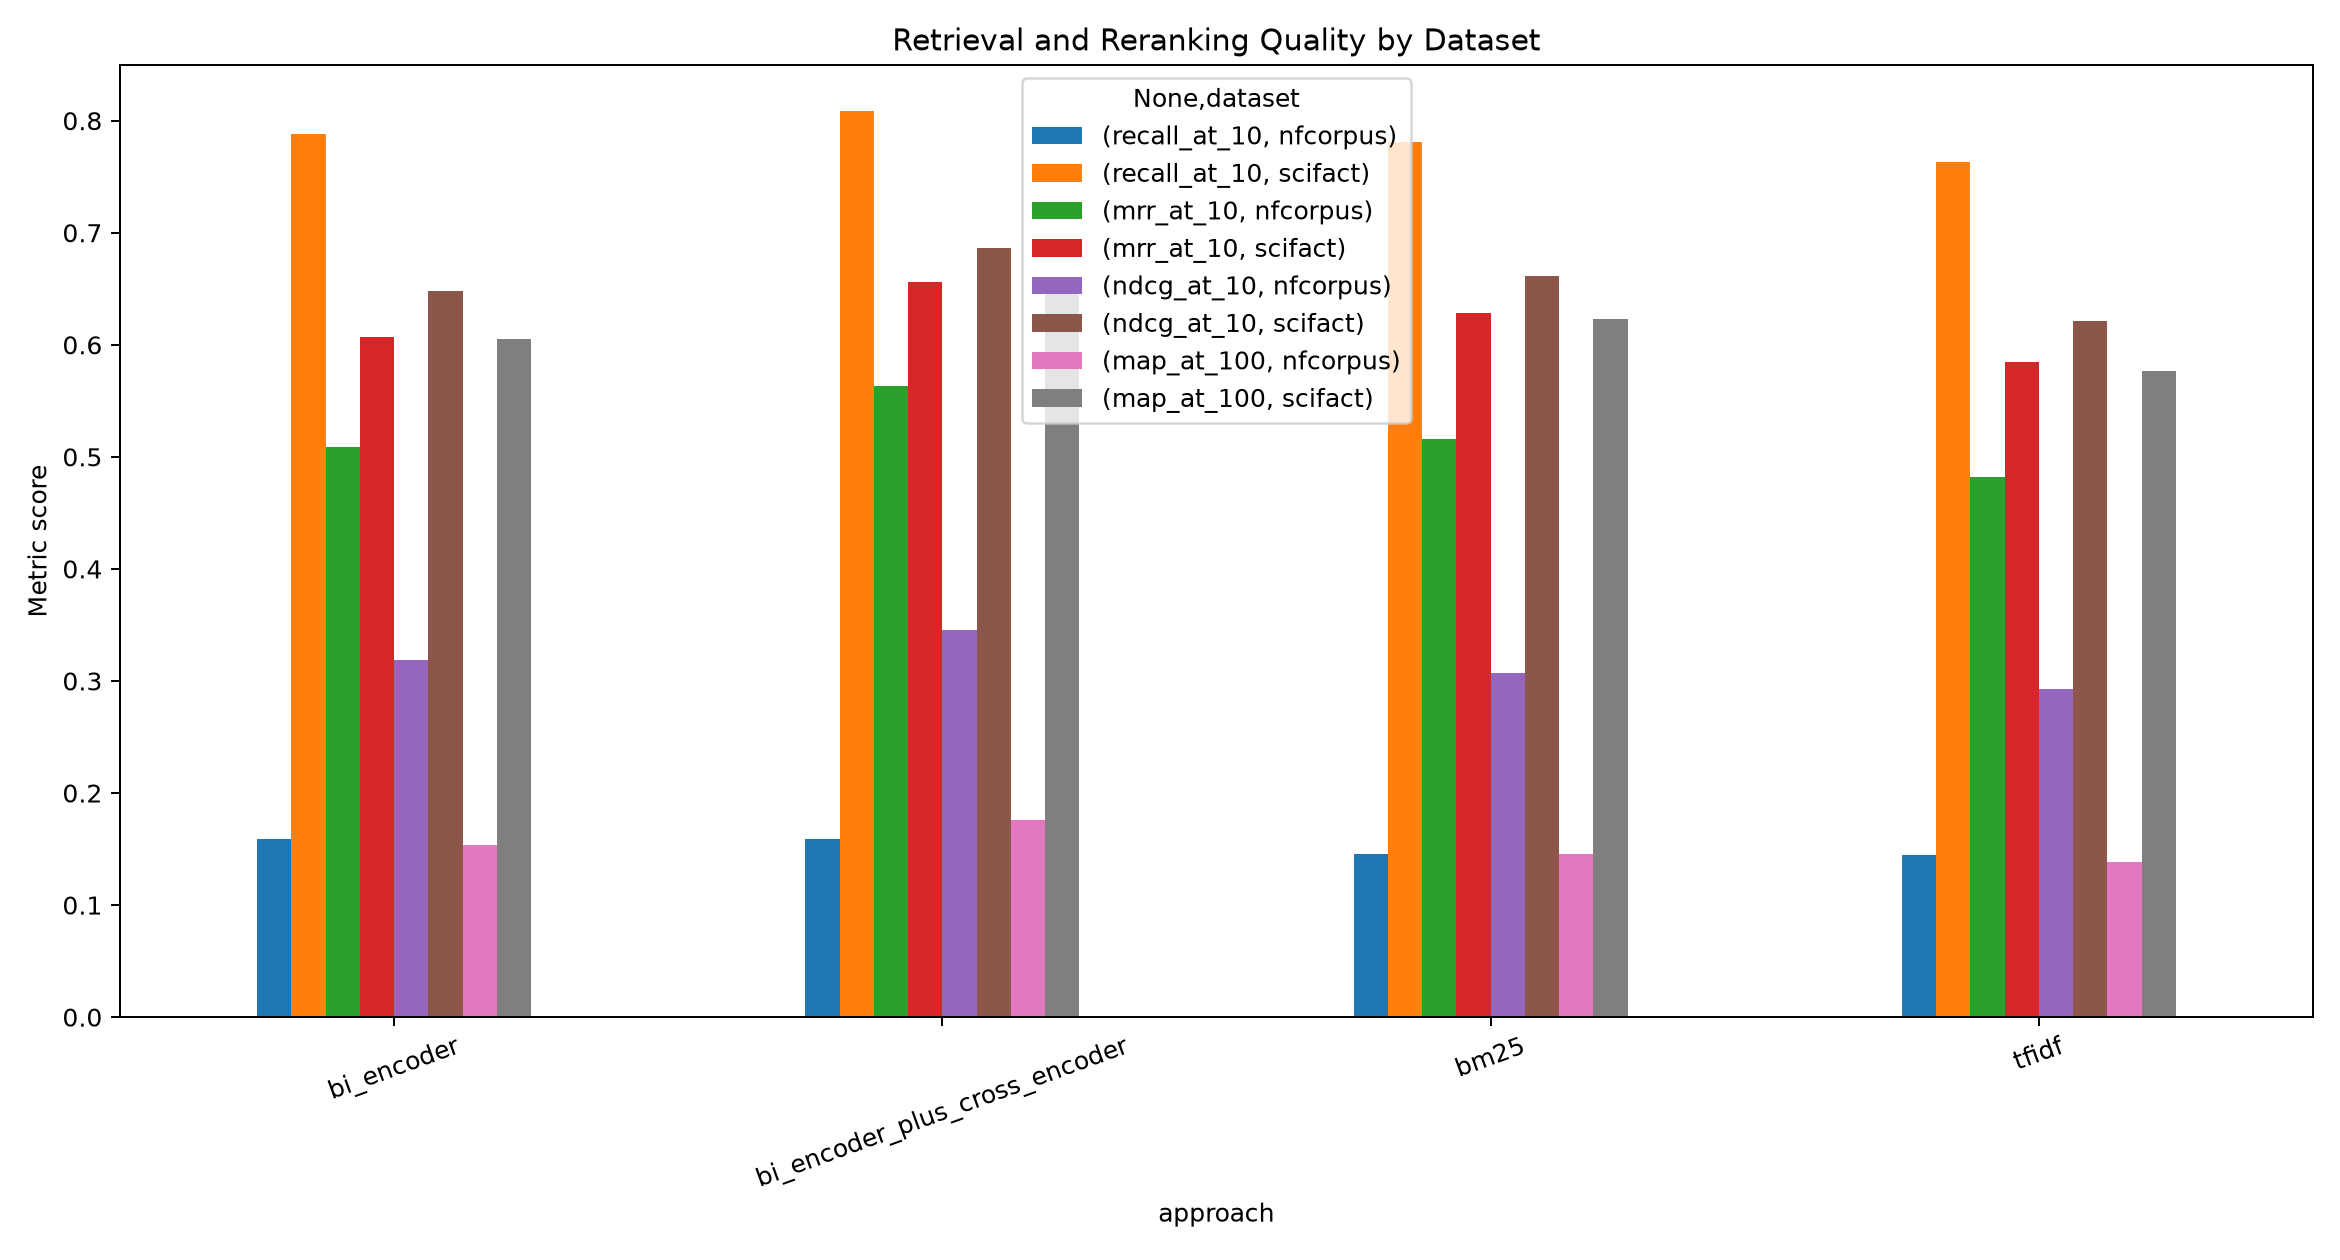

recall_at_k_curves.png


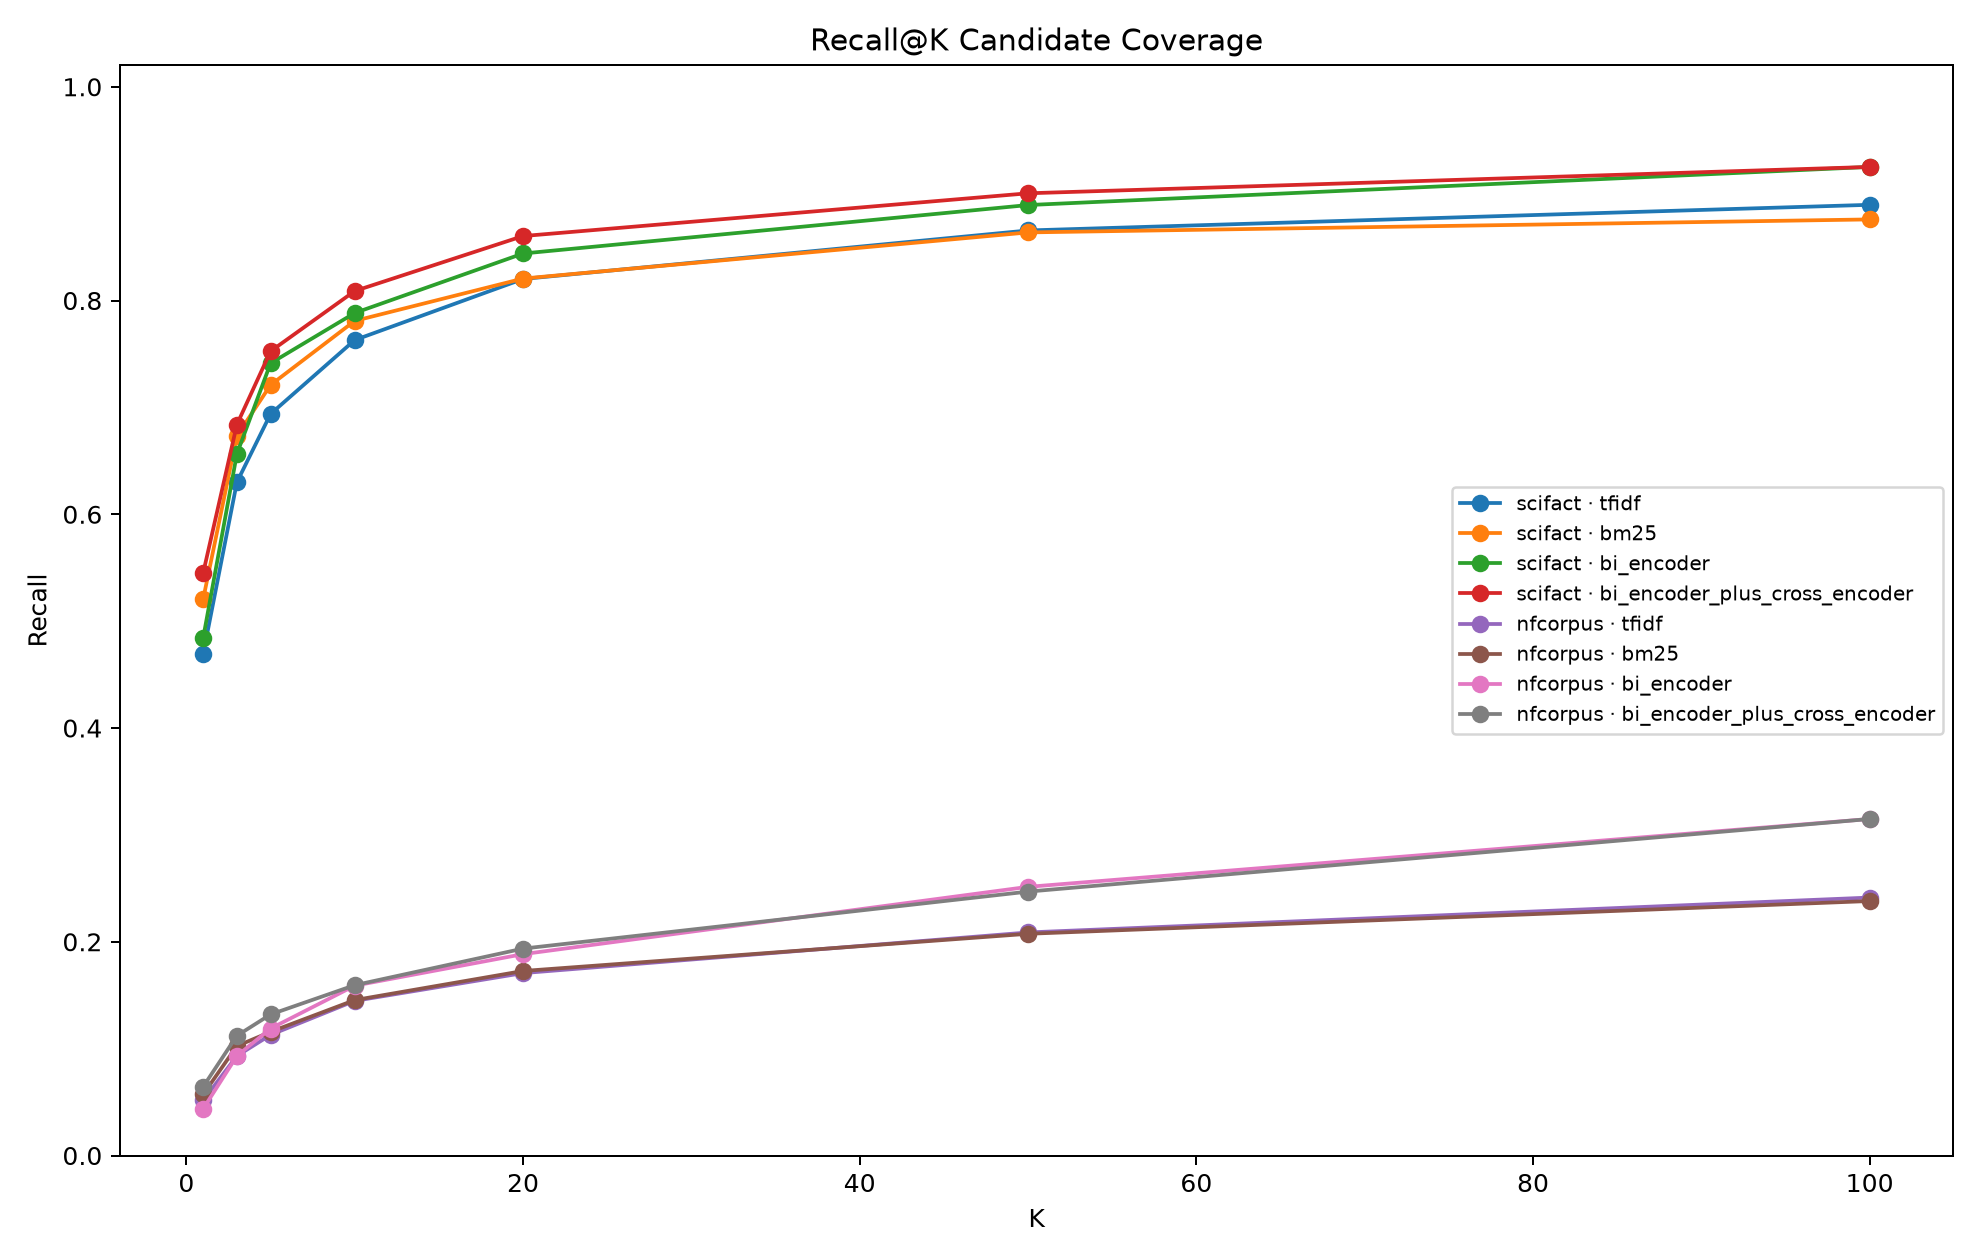

latency_comparison.png


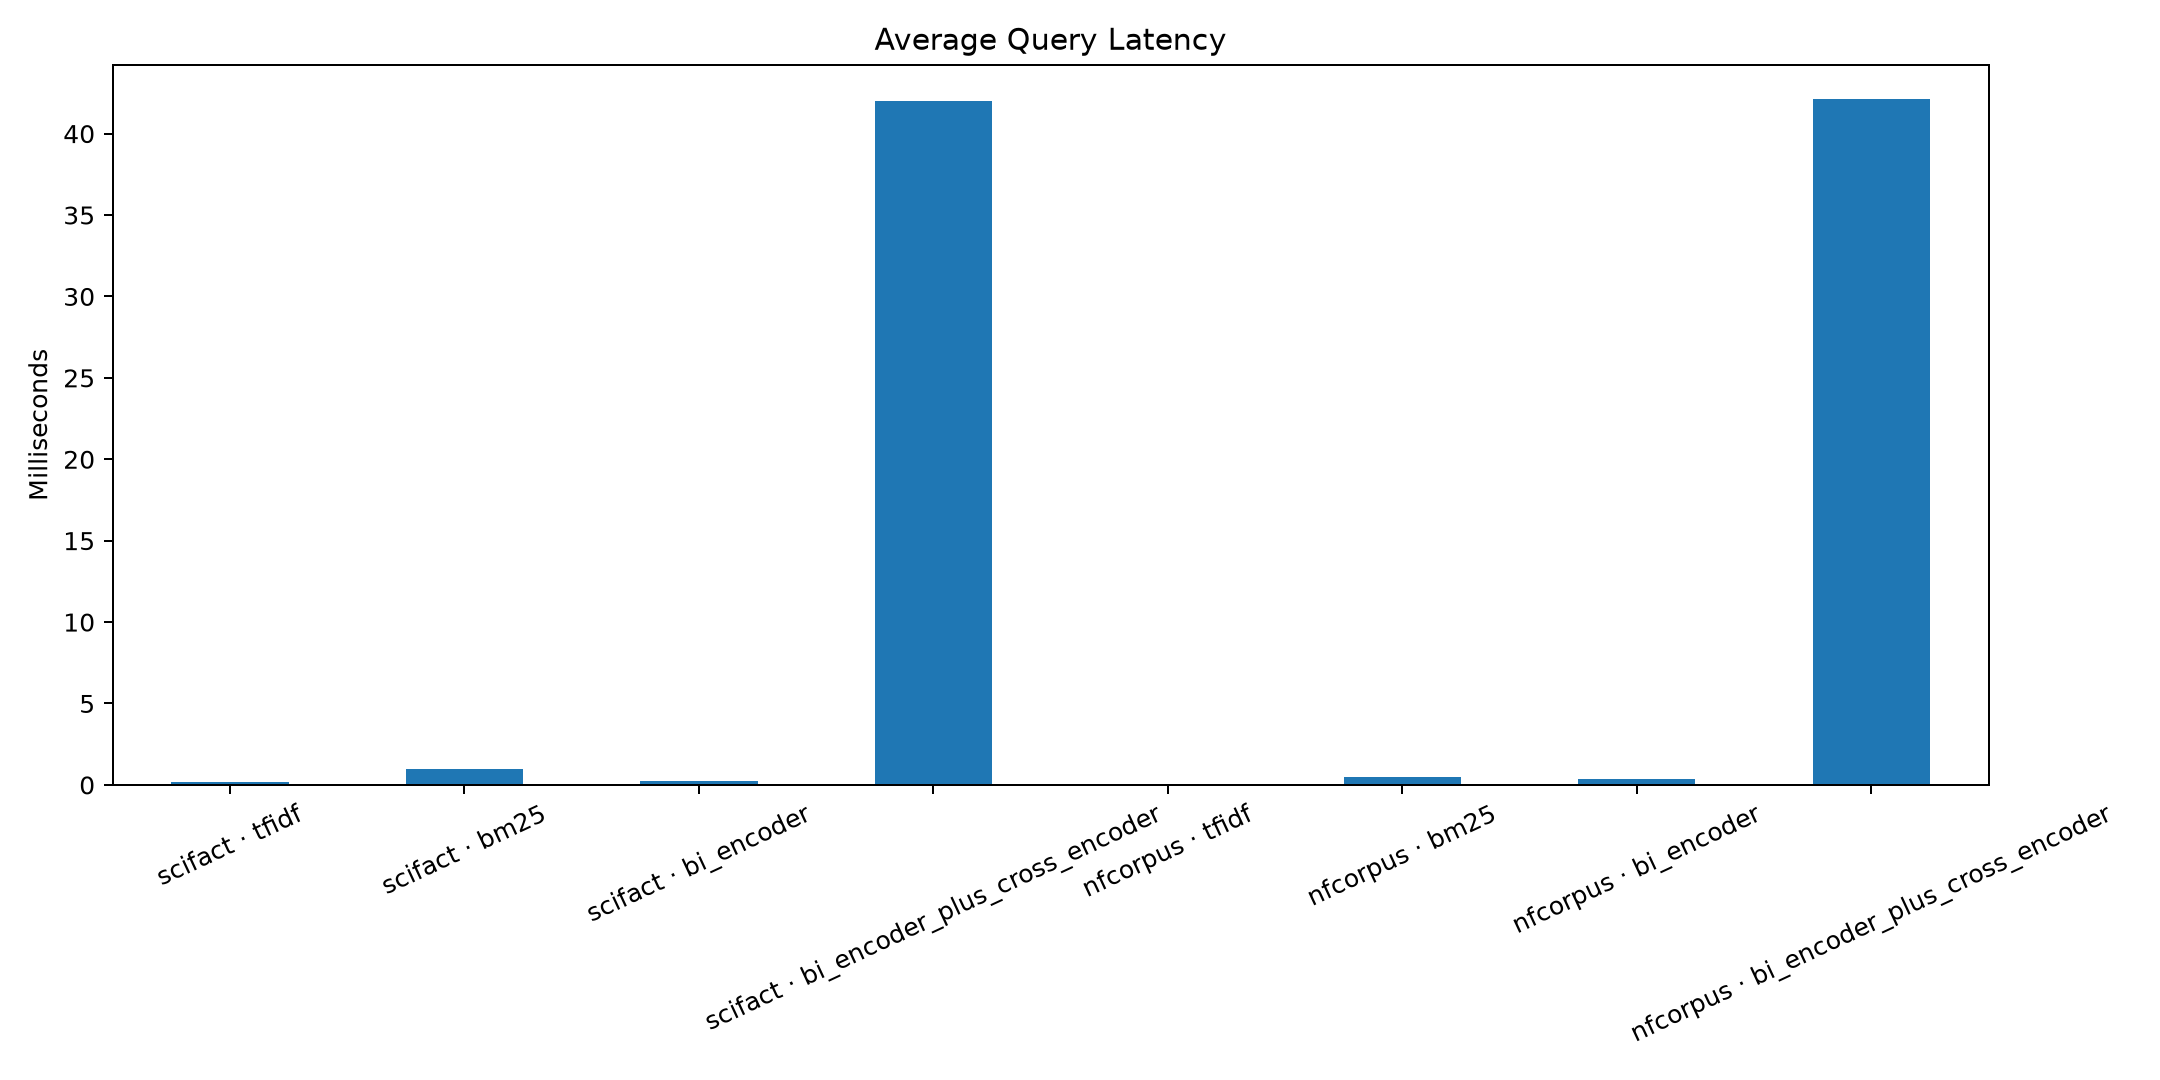

reranking_delta_distribution.png


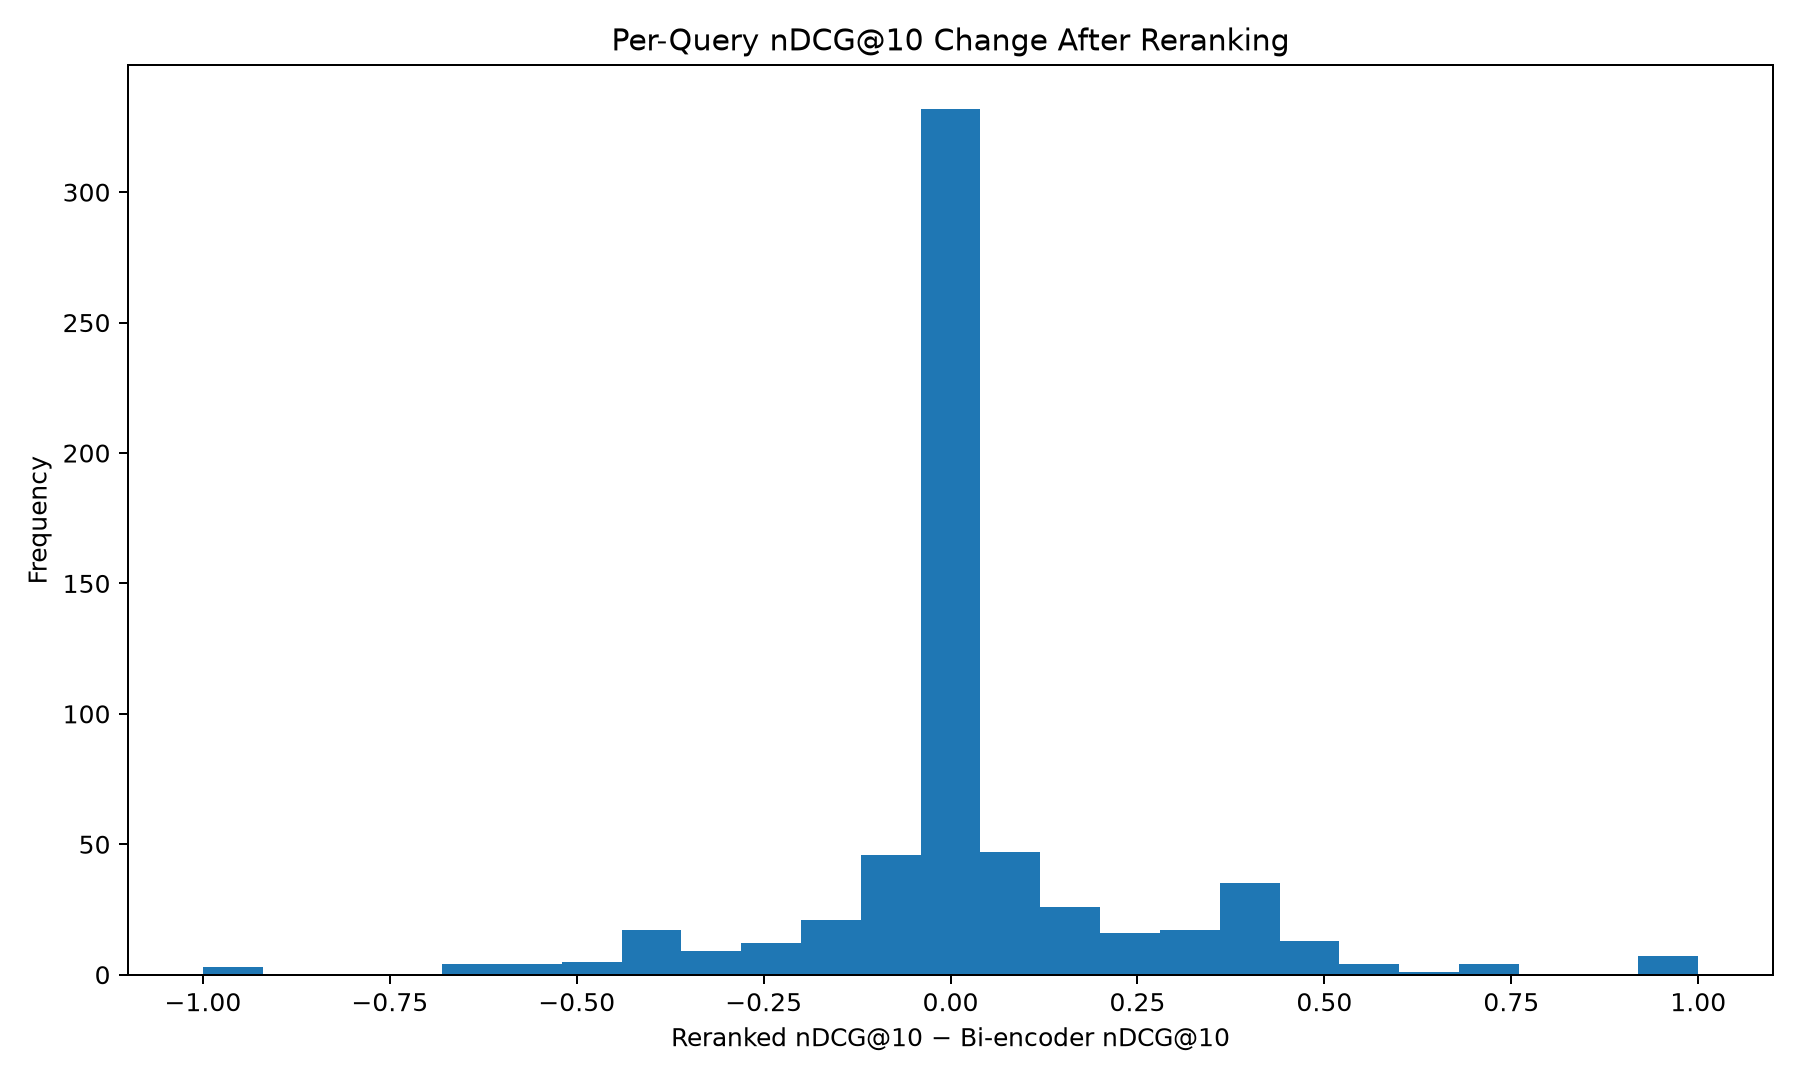

In [11]:
from IPython.display import Image, display as show

for filename in [
    "metric_comparison.png",
    "recall_at_k_curves.png",
    "latency_comparison.png",
    "reranking_delta_distribution.png",
]:
    path = LATEST / filename
    if path.exists():
        print(filename)
        show(Image(filename=str(path)))


## 10. Sync verified results into GitHub and the Model Hub card

Run this only after reviewing the metrics and examples. It creates:

- `BENCHMARK_RESULTS.md`
- `model_hub/pipeline-card/evaluation_results.json`


In [12]:
from scripts.sync_benchmark_results import main as sync_benchmark_results

SYNC_VERIFIED_RESULTS = True
if SYNC_VERIFIED_RESULTS and base_result is not None:
    sync_benchmark_results()


Updated model_hub/pipeline-card/evaluation_results.json
Created BENCHMARK_RESULTS.md


# Optional advanced upgrade — Fine-tune the bi-encoder

The rigorous base-model benchmark is enough to move the portfolio project close
to a **9/10** because it adds recognized datasets, strong baselines, actual
metrics, latency and statistical evidence.

Fine-tuning is an additional upgrade. It allows you to truthfully publish your
own derived bi-encoder model when training and held-out evaluation complete.

The training pipeline uses:

- SciFact **train** split
- BM25 hard negatives
- `MultipleNegativesRankingLoss`
- BF16 on supported RTX GPUs, otherwise FP16
- SciFact **test** and NFCorpus **test** for evaluation


In [13]:
from src.benchmarking.training import FineTuneConfig, fine_tune_bi_encoder

RUN_FINE_TUNING = False

FINE_TUNE_CONFIG = FineTuneConfig(
    project_root=PROJECT_ROOT,
    base_model="sentence-transformers/all-MiniLM-L6-v2",
    dataset_name="scifact",
    split="train",
    output_name="docrank360-minilm-scifact",
    device="cuda",
    epochs=2.0,
    batch_size=32,
    gradient_accumulation_steps=1,
    learning_rate=2e-5,
    hard_negative_pool=50,
)

training_metadata = None
if RUN_FINE_TUNING:
    training_metadata = fine_tune_bi_encoder(FINE_TUNE_CONFIG)
    print(json.dumps(training_metadata, indent=2))


## 11. Evaluate the fine-tuned model on held-out datasets

This step must use test data only. Comparing SciFact and NFCorpus helps separate
in-domain gains from generalization losses.


In [14]:
RUN_FINE_TUNED_BENCHMARK = False

fine_tuned_result = None
fine_tuned_model_path = (
    PROJECT_ROOT / "models" / "fine_tuned" / "docrank360-minilm-scifact"
)

if RUN_FINE_TUNED_BENCHMARK:
    assert fine_tuned_model_path.exists(), "Run fine-tuning first."
    fine_tuned_config = BenchmarkConfig(
        project_root=PROJECT_ROOT,
        datasets=DATASETS,
        split="test",
        bi_encoder_model=str(fine_tuned_model_path),
        cross_encoder_model="cross-encoder/ms-marco-MiniLM-L-6-v2",
        model_label="fine_tuned_scifact",
        device="cuda",
        candidate_k=CANDIDATE_K,
        rerank_k=RERANK_K,
        bi_encoder_batch_size=BI_ENCODER_BATCH_SIZE,
        cross_encoder_batch_size=CROSS_ENCODER_BATCH_SIZE,
        bootstrap_samples=BOOTSTRAP_SAMPLES,
        run_name="fine-tuned-scifact-beir-final",
    )
    fine_tuned_result = run_benchmark_suite(fine_tuned_config)
    display(fine_tuned_result.summary)


## 12. Compare base and fine-tuned models

A fine-tuned model is worth publishing only when the measured results justify
it. Report both improvements and regressions.


In [15]:
if base_result is not None and fine_tuned_result is not None:
    comparison = pd.concat(
        [base_result.summary, fine_tuned_result.summary],
        ignore_index=True,
    )
    display(
        comparison[
            [
                "model_label",
                "dataset",
                "approach",
                "recall_at_10",
                "mrr_at_10",
                "ndcg_at_10",
                "map_at_100",
                "mean_query_ms",
            ]
        ].round(4)
    )


# Final completion checklist

Before pushing the upgraded project:

- [ ] CUDA is detected and GPU information is saved.
- [ ] SciFact and NFCorpus base-model benchmarks completed.
- [ ] TF-IDF and BM25 baseline rows exist.
- [ ] Bi-encoder and two-stage Transformer rows exist.
- [ ] MRR@10, nDCG@10, MAP@100 and Recall@K contain real values.
- [ ] Bootstrap confidence intervals were generated.
- [ ] Improvements and regressions were manually reviewed.
- [ ] Charts were generated.
- [ ] `sync_benchmark_results.py` completed.
- [ ] Optional fine-tuned model was evaluated on held-out test data before any Model Hub upload.
- [ ] No private or confidential data appears in outputs.

Git commands:

```bash
git add "03-cross-encoder-bi-encoder-ranking-system" ".github/workflows/03-cross-encoder-bi-encoder-ranking-system.yml"
git commit -m "Upgrade Project 03 with large-scale BEIR evaluation and GPU benchmarking"
git push origin main
```
